In [ ]:
import pandas as pd
import numpy as np

In [ ]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

In [ ]:
merged = pd.merge(ratings, movies, on='movieId', how='inner')
merged = merged.drop(columns=['timestamp', 'genres'])

In [ ]:
# merged.to_csv("merged.csv", index=False)

In [ ]:
user_movie_matrix = merged.pivot_table(index='userId', columns='movieId', values='rating')
user_movie_matrix = user_movie_matrix.fillna(0)
print(user_movie_matrix)
A = user_movie_matrix.values
print(f"Matrix shape: {A.shape}")

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...         ...     ...     ...     ...     ...     ...     ...     ...   
606         2.5     0.0     0.0     0.0     0.0     0.0     2.5     0.0   
607         4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
608         2.5     2.0     2.0     0.0     0.0     0.0     0.0     0.0   
609         3.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
610         5.0     0.0     0.0     0.0     0.0     5.0     0.0     0.0   

movieId  9       10     

In [ ]:
ratings_per_user = (user_movie_matrix != 0).sum(axis=1)
user_movie_matrix = user_movie_matrix[ratings_per_user >= 50] # filters out rows to ignore users with <50 ratings
print(user_movie_matrix)

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
6           0.0     4.0     5.0     3.0     5.0     4.0     4.0     3.0   
7           4.5     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
10          0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...         ...     ...     ...     ...     ...     ...     ...     ...   
605         4.0     3.5     0.0     0.0     0.0     0.0     0.0     0.0   
606         2.5     0.0     0.0     0.0     0.0     0.0     2.5     0.0   
607         4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
608         2.5     2.0     2.0     0.0     0.0     0.0     0.0     0.0   
610         5.0     0.0     0.0     0.0     0.0     5.0     0.0     0.0   

movieId  9       10     

In [ ]:
A = user_movie_matrix.values
print(f"Matrix shape: {A.shape}")
print(f"Sparsity: {1 - np.count_nonzero(A) / A.size:.2%}")

Matrix shape: (385, 9724)
Sparsity: 97.49%


In [ ]:
from numpy.linalg import eigh, norm

In [ ]:
# train/test split
# returning 2D array of every (user, movie) pair that has a real rating
known_indices = np.argwhere (A != 0)

# make results reproducible by setting random seed
np.random.seed(42)

#shuffle list of known (user,movie) pairs in place
np.random.shuffle(known_indices)

#hold out 10% of ratings for testing, floor to whole number
split = int(0.1 * len(known_indices))
test_idx = known_indices[:split]
train_idx = known_indices[split:]

#make copy of A to use as training matrix
A_train = A.copy().astype(float)

#"hide" the 10% of test ratings from the model
for i, j in test_idx:
    A_train[i, j] = 0

#build array of the actual (true) ratings at all test positions
# to compare predictions later
actuals = np.array([A[i, j] for i, j in test_idx])

In [ ]:
#eigendecompose a transpose a, getting V^T
#ev --> eigen values
#V --> eigen vectors
ev, V = eigh(A_train.T @ A_train)
# eigh returns eigenvalues smallest-first, but SVD convention is largest-first
ev = ev[::-1]
V = V[:, ::-1]

In [ ]:
U = np.zeros((A_train.shape[0], V.shape[1]))
for i in range(V.shape[1]):
    col = A_train @ V[:, i]
    n = norm(col)
    if n > 1e-10:  # avoid dividing by zero
        U[:, i] = col / n

# singular values are the square roots of the eigenvalues
# larger sigmas mean that latent factor explains more variance in the data
sigma = np.sqrt(np.maximum(ev, 0))
Vt = V.T

In [ ]:
#baselines: global mean and user mean
global_mean = A_train[A_train != 0].mean()
counts = (A_train != 0).sum(axis=1)
user_means = A_train.sum(axis=1) / np.where(counts==0,1,counts)
user_mean_preds = np.array([user_means[i] for i,j in test_idx])


In [ ]:
# make copy of A_train to apply mean-centering
A_centered = A_train.copy()

# for each user, subtract their mean rating from every rating they gave
for i in range (A_centered.shape[0]):
  A_centered[i, A_centered[i] != 0] -= user_means[i]

# run eigendecomposition on the mean-centered matrix
ev_c, V_c = eigh(A_centered.T @ A_centered)
ev_c = ev_c[::-1]
V_c = V_c[:, ::-1]

U_c = np.zeros((A_centered.shape[0], V_c.shape[1]))
for i in range (V_c.shape[1]):
  col = A_centered @ V_c[:, i]
  n = norm(col)
  if n > 1e-10:
    U_c[:, i] = col / n

sigma_c = np.sqrt(np.maximum(ev_c, 0))
Vt_c = V_c.T

In [ ]:
# rmse function: lower rmse = better predictions
def rmse(preds, actuals):
  return np.sqrt(np.mean((preds - actuals) ** 2))

# loop over k values
import matplotlib.pyplot as plt

# test values of k from 2 to 51
k_values = list(range(2,51))

# empty lists to store rmse at each k
rmse_raw, rmse_centered = [],[]

for k in k_values:
  # reconstruct rank k-approximation using only the k most important lantent factors
  Ak = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]

  Ak = np.clip(Ak, 1, 5)

  # for each test position (i,j) get predicted rating from k-rank matrix
  preds = np.array([Ak[i, j] for i, j in test_idx])

  # calculate rmse for raw matrix
  rmse_raw.append(rmse(preds, actuals))

  # for mean-centered SVD, same rank-k construction:
  Ak_c = U_c[:, :k] @ np.diag(sigma_c[:k]) @ Vt_c[:k, :]

  # add each user's mean back (we subtracted it before SVD)
  for i in range (Ak_c.shape[0]):
    Ak_c[i, :] += user_means[i]

  # force all predicted values into valid 1-5 range
  Ak_c = np.clip(Ak_c, 1, 5)
  preds_c = np.array([Ak_c[i, j] for i, j in test_idx])

  # calculate rmse for mean-centered matrix
  rmse_centered.append(rmse(preds_c, actuals))


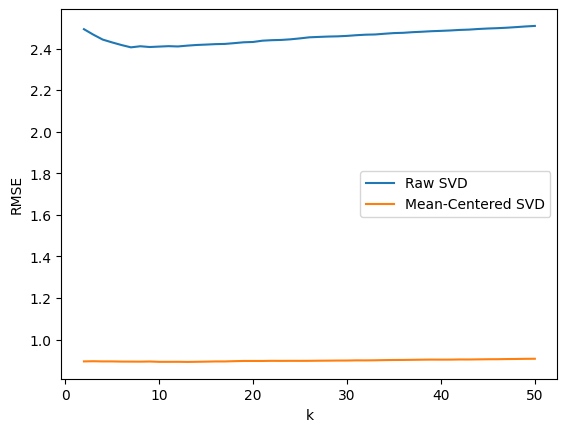

In [ ]:
# rmse vs k plot
plt.plot(k_values, rmse_raw, label='Raw SVD')
plt.plot(k_values, rmse_centered, label='Mean-Centered SVD')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [ ]:
# print
best_k = k_values[np.argmin(rmse_raw)]
best_k_c = k_values[np.argmin(rmse_centered)]
print("RMSE comparison")
print(f"Global Mean baseline: {rmse(np.full(len(actuals), global_mean), actuals)}")
print(f"User Mean baseline: {rmse(user_mean_preds, actuals)}")
print(f"Raw SVD best k: {best_k}, RMSE: {rmse_raw[np.argmin(rmse_raw)]}")
print(f"Mean-Centered SVD best k: {best_k_c}, RMSE: {rmse_centered[np.argmin(rmse_centered)]}")


RMSE comparison
Global Mean baseline: 1.0326980154755243
User Mean baseline: 0.9279873964973209
Raw SVD best k: 7, RMSE: 2.40555523014863
Mean-Centered SVD best k: 13, RMSE: 0.8928688642489202


In [ ]:
for factor_idx in range(5):
  # get factor_idx row of Vt, all cols
  factor_scores = Vt[factor_idx, :]

  # get movieId labels from the matrix cols
  movie_ids = user_movie_matrix.columns.tolist()

  # create df for movies and scores
  factor_df = pd.DataFrame({
      'movieId': movie_ids,
      'score': factor_scores
  })

  # merge with original movies table
  factor_df = factor_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')

  # sort by score descending
  factor_df = factor_df.sort_values('score', ascending=False)

  # print first and last 15 rows
  print("TOP OF FACTOR", factor_idx)
  print(factor_df.head(15)[['title', 'genres', 'score']])

  print("BOTTOM OF FACTOR", factor_idx)
  print(factor_df.tail(15)[['title', 'genres', 'score']])


TOP OF FACTOR 0
                                                  title  \
314                                 Forrest Gump (1994)   
1938                                 Matrix, The (1999)   
224           Star Wars: Episode IV - A New Hope (1977)   
257                                 Pulp Fiction (1994)   
277                    Shawshank Redemption, The (1994)   
510                    Silence of the Lambs, The (1991)   
2224                                  Fight Club (1999)   
897   Star Wars: Episode V - The Empire Strikes Back...   
910   Star Wars: Episode VI - Return of the Jedi (1983)   
659                               Godfather, The (1972)   
2144                             American Beauty (1999)   
507                   Terminator 2: Judgment Day (1991)   
899   Raiders of the Lost Ark (Indiana Jones and the...   
3633  Lord of the Rings: The Fellowship of the Ring,...   
1502                         Saving Private Ryan (1998)   

                           genres     s